<h1>
Job Application Analysis
</h1>
<p>
Wowie gonna be a fun one!
</p>

In [184]:
import pandas as pd

#load handshake df
df_h = pd.read_csv("Handshake/handshake_applications.csv")

#load linkedin df
df_l = pd.read_csv("LinkedIn/linkedin_applications_full.csv")



df_h.head()

,job_id,employer,industry,title,location_raw,work_type,city,state,date_applied,status,source_page
0,11022175.0,Sony Music Entertainment,"Movies, TV, Music, Gaming",Environmental Social Governance Specialist,"Onsite, based in Los Angeles, CA",Onsite,Los Angeles,CA,2026-05-08,Applied,0
1,11005041.0,Heartflow,Medical Devices,Make an Impact - Imaging Analyst at Heartflow ...,"Hybrid, based in Austin, TX",NaN,Austin,TX,2026-05-08,Applied,0
2,10905518.0,Cobbs Creek Healthcare,Pharmaceuticals,Data Analyst - Junior,"Onsite, based in Newtown Square, PA",Onsite,Newtown Square,PA,2026-04-29,Applied,0
3,10997336.0,Walther Farms,Agriculture,IT Systems & Data Administrator,"Hybrid or onsite, based in Three Rivers, MI",NaN,Three Rivers,MI,2026-04-29,Applied,0
4,10935270.0,Ekimetrics,Scientific and Technical Consulting,"Junior Business Scientist, Data Science and Ma...","Hybrid, based in New York, NY",NaN,New York,NY,2026-04-29,Applied,0


In [185]:
df_l

,title,company_location,applied_date_raw,extra_status,url,file,applied_date,month
0,Data Engineer,Addison Group · United States (Remote),Applied 3w ago,(No longer accepting applications),https://www.linkedin.com/jobs/view/4402760008/,1.html,NaN,NaN
1,Data Scientist / Engineer (Healthcare Solutions),"Shift Technology · Boston, MA (Hybrid)",Applied 1d ago,(Reposted 6d ago),https://www.linkedin.com/jobs/view/4389759683/,1.html,NaN,NaN
2,Junior Support Engineer,"Bracebridge Capital, LLC · Boston, MA",Applied 1d ago,(Reposted 2w ago),https://www.linkedin.com/jobs/view/4394477424/,1.html,NaN,NaN
3,Associate – AI & Automation (Early Career / Ne...,"BETSOL · Broomfield, CO (On-site)",Applied 1w ago,(No longer accepting applications),https://www.linkedin.com/jobs/view/4397324427/,1.html,NaN,NaN
4,"Software Engineer, Data Engineering","Neuralink · Fremont, CA",Applied 3w ago,(Reposted 5d ago),https://www.linkedin.com/jobs/view/4389802889/,1.html,NaN,NaN
...,...,...,...,...,...,...,...,...
676,Product Management (Data Analysis) Intern (Sum...,"BoldVoice · New York, NY (On-site)",Applied 9mo ago,(No longer accepting applications),https://www.linkedin.com/jobs/view/4263476867/,69.html,NaN,NaN
677,Data Engineer,"Vertex Elite LLC · San Francisco, CA (Hybrid)",Applied 10mo ago,(No longer accepting applications),https://www.linkedin.com/jobs/view/4263386707/,69.html,NaN,NaN
678,Database Specialist,"Mastech Digital · Chicago, IL (Hybrid)",Applied 9mo ago,(No longer accepting applications),https://www.linkedin.com/jobs/view/4255404488/,69.html,NaN,NaN
679,Power BI Admin/Developer (Microsoft Fabric Foc...,"Bolingbrook, IL • (Hybrid)",Applied 9mo ago,(No longer accepting applications),https://www.linkedin.com/jobs/view/4264478550/,70.html,NaN,NaN


In [186]:
# extracting company, city, and state into new cols

df_l[["company", "city", "state"]] = df_l["company_location"].str.extract(
    r"^\s*([^·]+)\s*·\s*(?:([^,()]+),\s*([A-Z]{2}))?"
)

In [187]:
df_l

,title,company_location,applied_date_raw,extra_status,url,file,applied_date,month,company,city,state
0,Data Engineer,Addison Group · United States (Remote),Applied 3w ago,(No longer accepting applications),https://www.linkedin.com/jobs/view/4402760008/,1.html,NaN,NaN,Addison Group,NaN,NaN
1,Data Scientist / Engineer (Healthcare Solutions),"Shift Technology · Boston, MA (Hybrid)",Applied 1d ago,(Reposted 6d ago),https://www.linkedin.com/jobs/view/4389759683/,1.html,NaN,NaN,Shift Technology,Boston,MA
2,Junior Support Engineer,"Bracebridge Capital, LLC · Boston, MA",Applied 1d ago,(Reposted 2w ago),https://www.linkedin.com/jobs/view/4394477424/,1.html,NaN,NaN,"Bracebridge Capital, LLC",Boston,MA
3,Associate – AI & Automation (Early Career / Ne...,"BETSOL · Broomfield, CO (On-site)",Applied 1w ago,(No longer accepting applications),https://www.linkedin.com/jobs/view/4397324427/,1.html,NaN,NaN,BETSOL,Broomfield,CO
4,"Software Engineer, Data Engineering","Neuralink · Fremont, CA",Applied 3w ago,(Reposted 5d ago),https://www.linkedin.com/jobs/view/4389802889/,1.html,NaN,NaN,Neuralink,Fremont,CA
...,...,...,...,...,...,...,...,...,...,...,...
676,Product Management (Data Analysis) Intern (Sum...,"BoldVoice · New York, NY (On-site)",Applied 9mo ago,(No longer accepting applications),https://www.linkedin.com/jobs/view/4263476867/,69.html,NaN,NaN,BoldVoice,New York,NY
677,Data Engineer,"Vertex Elite LLC · San Francisco, CA (Hybrid)",Applied 10mo ago,(No longer accepting applications),https://www.linkedin.com/jobs/view/4263386707/,69.html,NaN,NaN,Vertex Elite LLC,San Francisco,CA
678,Database Specialist,"Mastech Digital · Chicago, IL (Hybrid)",Applied 9mo ago,(No longer accepting applications),https://www.linkedin.com/jobs/view/4255404488/,69.html,NaN,NaN,Mastech Digital,Chicago,IL
679,Power BI Admin/Developer (Microsoft Fabric Foc...,"Bolingbrook, IL • (Hybrid)",Applied 9mo ago,(No longer accepting applications),https://www.linkedin.com/jobs/view/4264478550/,70.html,NaN,NaN,NaN,NaN,NaN


In [188]:
import re
import pandas as pd

today = pd.Timestamp("2026-05-12")

def parse_linkedin_applied_date(s):
    match = re.search(r"Applied\s+(\d+)(d|w|mo|y)\s+ago", str(s))
    
    if not match:
        return pd.NaT
    
    value = int(match.group(1))
    unit = match.group(2)

    if unit == "d":
        dt = today - pd.Timedelta(days=value)
    elif unit == "w":
        dt = today - pd.Timedelta(weeks=value)
    elif unit == "mo":
        dt = today - pd.DateOffset(months=value)
    elif unit == "y":
        dt = today - pd.DateOffset(years=value)

    return dt.strftime("%Y-%m-%d")
df_l["applied_date"] = df_l["applied_date_raw"].apply(parse_linkedin_applied_date)

In [189]:
df_l

,title,company_location,applied_date_raw,extra_status,url,file,applied_date,month,company,city,state
0,Data Engineer,Addison Group · United States (Remote),Applied 3w ago,(No longer accepting applications),https://www.linkedin.com/jobs/view/4402760008/,1.html,2026-04-21,NaN,Addison Group,NaN,NaN
1,Data Scientist / Engineer (Healthcare Solutions),"Shift Technology · Boston, MA (Hybrid)",Applied 1d ago,(Reposted 6d ago),https://www.linkedin.com/jobs/view/4389759683/,1.html,2026-05-11,NaN,Shift Technology,Boston,MA
2,Junior Support Engineer,"Bracebridge Capital, LLC · Boston, MA",Applied 1d ago,(Reposted 2w ago),https://www.linkedin.com/jobs/view/4394477424/,1.html,2026-05-11,NaN,"Bracebridge Capital, LLC",Boston,MA
3,Associate – AI & Automation (Early Career / Ne...,"BETSOL · Broomfield, CO (On-site)",Applied 1w ago,(No longer accepting applications),https://www.linkedin.com/jobs/view/4397324427/,1.html,2026-05-05,NaN,BETSOL,Broomfield,CO
4,"Software Engineer, Data Engineering","Neuralink · Fremont, CA",Applied 3w ago,(Reposted 5d ago),https://www.linkedin.com/jobs/view/4389802889/,1.html,2026-04-21,NaN,Neuralink,Fremont,CA
...,...,...,...,...,...,...,...,...,...,...,...
676,Product Management (Data Analysis) Intern (Sum...,"BoldVoice · New York, NY (On-site)",Applied 9mo ago,(No longer accepting applications),https://www.linkedin.com/jobs/view/4263476867/,69.html,2025-08-12,NaN,BoldVoice,New York,NY
677,Data Engineer,"Vertex Elite LLC · San Francisco, CA (Hybrid)",Applied 10mo ago,(No longer accepting applications),https://www.linkedin.com/jobs/view/4263386707/,69.html,2025-07-12,NaN,Vertex Elite LLC,San Francisco,CA
678,Database Specialist,"Mastech Digital · Chicago, IL (Hybrid)",Applied 9mo ago,(No longer accepting applications),https://www.linkedin.com/jobs/view/4255404488/,69.html,2025-08-12,NaN,Mastech Digital,Chicago,IL
679,Power BI Admin/Developer (Microsoft Fabric Foc...,"Bolingbrook, IL • (Hybrid)",Applied 9mo ago,(No longer accepting applications),https://www.linkedin.com/jobs/view/4264478550/,70.html,2025-08-12,NaN,NaN,NaN,NaN


In [190]:
df_l["company_location_clean"] = (
    df_l["company_location"]
    .str.replace(r"[^\w\s]", " ", regex=True)
    .str.lower()
)

conditions = [
    df_l["company_location_clean"].str.contains(r"\bremote\b", na=False),
    df_l["company_location_clean"].str.contains(r"\bhybrid\b", na=False),
]

df_l["work_type"] = np.select(conditions, ["Remote", "Hybrid"], default="Onsite")

In [191]:
df_l

,title,company_location,applied_date_raw,extra_status,url,file,applied_date,month,company,city,state,company_location_clean,work_type
0,Data Engineer,Addison Group · United States (Remote),Applied 3w ago,(No longer accepting applications),https://www.linkedin.com/jobs/view/4402760008/,1.html,2026-04-21,NaN,Addison Group,NaN,NaN,addison group united states remote,Remote
1,Data Scientist / Engineer (Healthcare Solutions),"Shift Technology · Boston, MA (Hybrid)",Applied 1d ago,(Reposted 6d ago),https://www.linkedin.com/jobs/view/4389759683/,1.html,2026-05-11,NaN,Shift Technology,Boston,MA,shift technology boston ma hybrid,Hybrid
2,Junior Support Engineer,"Bracebridge Capital, LLC · Boston, MA",Applied 1d ago,(Reposted 2w ago),https://www.linkedin.com/jobs/view/4394477424/,1.html,2026-05-11,NaN,"Bracebridge Capital, LLC",Boston,MA,bracebridge capital llc boston ma,Onsite
3,Associate – AI & Automation (Early Career / Ne...,"BETSOL · Broomfield, CO (On-site)",Applied 1w ago,(No longer accepting applications),https://www.linkedin.com/jobs/view/4397324427/,1.html,2026-05-05,NaN,BETSOL,Broomfield,CO,betsol broomfield co on site,Onsite
4,"Software Engineer, Data Engineering","Neuralink · Fremont, CA",Applied 3w ago,(Reposted 5d ago),https://www.linkedin.com/jobs/view/4389802889/,1.html,2026-04-21,NaN,Neuralink,Fremont,CA,neuralink fremont ca,Onsite
...,...,...,...,...,...,...,...,...,...,...,...,...,...
676,Product Management (Data Analysis) Intern (Sum...,"BoldVoice · New York, NY (On-site)",Applied 9mo ago,(No longer accepting applications),https://www.linkedin.com/jobs/view/4263476867/,69.html,2025-08-12,NaN,BoldVoice,New York,NY,boldvoice new york ny on site,Onsite
677,Data Engineer,"Vertex Elite LLC · San Francisco, CA (Hybrid)",Applied 10mo ago,(No longer accepting applications),https://www.linkedin.com/jobs/view/4263386707/,69.html,2025-07-12,NaN,Vertex Elite LLC,San Francisco,CA,vertex elite llc san francisco ca hybrid,Hybrid
678,Database Specialist,"Mastech Digital · Chicago, IL (Hybrid)",Applied 9mo ago,(No longer accepting applications),https://www.linkedin.com/jobs/view/4255404488/,69.html,2025-08-12,NaN,Mastech Digital,Chicago,IL,mastech digital chicago il hybrid,Hybrid
679,Power BI Admin/Developer (Microsoft Fabric Foc...,"Bolingbrook, IL • (Hybrid)",Applied 9mo ago,(No longer accepting applications),https://www.linkedin.com/jobs/view/4264478550/,70.html,2025-08-12,NaN,NaN,NaN,NaN,bolingbrook il hybrid,Hybrid


In [192]:
# df_l.info()
# df_h.info()

# df_l dropping cols, applied_date_raw, url, file, month

df_l = df_l.drop(columns=["applied_date_raw", "url", "file", "month"])

In [193]:
df_l

,title,company_location,extra_status,applied_date,company,city,state,company_location_clean,work_type
0,Data Engineer,Addison Group · United States (Remote),(No longer accepting applications),2026-04-21,Addison Group,NaN,NaN,addison group united states remote,Remote
1,Data Scientist / Engineer (Healthcare Solutions),"Shift Technology · Boston, MA (Hybrid)",(Reposted 6d ago),2026-05-11,Shift Technology,Boston,MA,shift technology boston ma hybrid,Hybrid
2,Junior Support Engineer,"Bracebridge Capital, LLC · Boston, MA",(Reposted 2w ago),2026-05-11,"Bracebridge Capital, LLC",Boston,MA,bracebridge capital llc boston ma,Onsite
3,Associate – AI & Automation (Early Career / Ne...,"BETSOL · Broomfield, CO (On-site)",(No longer accepting applications),2026-05-05,BETSOL,Broomfield,CO,betsol broomfield co on site,Onsite
4,"Software Engineer, Data Engineering","Neuralink · Fremont, CA",(Reposted 5d ago),2026-04-21,Neuralink,Fremont,CA,neuralink fremont ca,Onsite
...,...,...,...,...,...,...,...,...,...
676,Product Management (Data Analysis) Intern (Sum...,"BoldVoice · New York, NY (On-site)",(No longer accepting applications),2025-08-12,BoldVoice,New York,NY,boldvoice new york ny on site,Onsite
677,Data Engineer,"Vertex Elite LLC · San Francisco, CA (Hybrid)",(No longer accepting applications),2025-07-12,Vertex Elite LLC,San Francisco,CA,vertex elite llc san francisco ca hybrid,Hybrid
678,Database Specialist,"Mastech Digital · Chicago, IL (Hybrid)",(No longer accepting applications),2025-08-12,Mastech Digital,Chicago,IL,mastech digital chicago il hybrid,Hybrid
679,Power BI Admin/Developer (Microsoft Fabric Foc...,"Bolingbrook, IL • (Hybrid)",(No longer accepting applications),2025-08-12,NaN,NaN,NaN,bolingbrook il hybrid,Hybrid


In [194]:
# useless cols in handshake data
df_h = df_h.drop(columns=["job_id", "location_raw", "source_page", "industry", "status"])
df_l = df_l.drop(columns=["company_location", "extra_status", "company_location_clean"])

In [195]:
df_h = df_h.rename(columns={
    "employer": "company",
    "date_applied": "applied_date"
})

In [196]:
df_h

,company,title,work_type,city,state,applied_date
0,Sony Music Entertainment,Environmental Social Governance Specialist,Onsite,Los Angeles,CA,2026-05-08
1,Heartflow,Make an Impact - Imaging Analyst at Heartflow ...,NaN,Austin,TX,2026-05-08
2,Cobbs Creek Healthcare,Data Analyst - Junior,Onsite,Newtown Square,PA,2026-04-29
3,Walther Farms,IT Systems & Data Administrator,NaN,Three Rivers,MI,2026-04-29
4,Ekimetrics,"Junior Business Scientist, Data Science and Ma...",NaN,New York,NY,2026-04-29
...,...,...,...,...,...,...
565,1010data,Data Science Intern,Remote/Hybrid,New York City,NY,2023-05-06
566,Ekimetrics,6 month Internship in Strategy & Data Science ...,Onsite,New York City,NY,2023-05-06
567,Management Systems International,Financial Management Team Intern,Remote/Hybrid,Arlington,VA,2023-05-06
568,Management Systems International,Strategic Evaluation and Analysis Intern,Remote/Hybrid,Arlington,VA,2023-05-06


In [197]:
df_l

,title,applied_date,company,city,state,work_type
0,Data Engineer,2026-04-21,Addison Group,NaN,NaN,Remote
1,Data Scientist / Engineer (Healthcare Solutions),2026-05-11,Shift Technology,Boston,MA,Hybrid
2,Junior Support Engineer,2026-05-11,"Bracebridge Capital, LLC",Boston,MA,Onsite
3,Associate – AI & Automation (Early Career / Ne...,2026-05-05,BETSOL,Broomfield,CO,Onsite
4,"Software Engineer, Data Engineering",2026-04-21,Neuralink,Fremont,CA,Onsite
...,...,...,...,...,...,...
676,Product Management (Data Analysis) Intern (Sum...,2025-08-12,BoldVoice,New York,NY,Onsite
677,Data Engineer,2025-07-12,Vertex Elite LLC,San Francisco,CA,Hybrid
678,Database Specialist,2025-08-12,Mastech Digital,Chicago,IL,Hybrid
679,Power BI Admin/Developer (Microsoft Fabric Foc...,2025-08-12,NaN,NaN,NaN,Hybrid


In [198]:
cols = ["title", "applied_date", "company", "city", "state", "work_type", "source"]

df_h["source"] = "Handshake"
df_l["source"] = "LinkedIn"

df_all = pd.concat([df_h, df_l], ignore_index=True)[cols]

In [199]:
df_all

,title,applied_date,company,city,state,work_type,source
0,Environmental Social Governance Specialist,2026-05-08,Sony Music Entertainment,Los Angeles,CA,Onsite,Handshake
1,Make an Impact - Imaging Analyst at Heartflow ...,2026-05-08,Heartflow,Austin,TX,NaN,Handshake
2,Data Analyst - Junior,2026-04-29,Cobbs Creek Healthcare,Newtown Square,PA,Onsite,Handshake
3,IT Systems & Data Administrator,2026-04-29,Walther Farms,Three Rivers,MI,NaN,Handshake
4,"Junior Business Scientist, Data Science and Ma...",2026-04-29,Ekimetrics,New York,NY,NaN,Handshake
...,...,...,...,...,...,...,...
1246,Product Management (Data Analysis) Intern (Sum...,2025-08-12,BoldVoice,New York,NY,Onsite,LinkedIn
1247,Data Engineer,2025-07-12,Vertex Elite LLC,San Francisco,CA,Hybrid,LinkedIn
1248,Database Specialist,2025-08-12,Mastech Digital,Chicago,IL,Hybrid,LinkedIn
1249,Power BI Admin/Developer (Microsoft Fabric Foc...,2025-08-12,NaN,NaN,NaN,Hybrid,LinkedIn


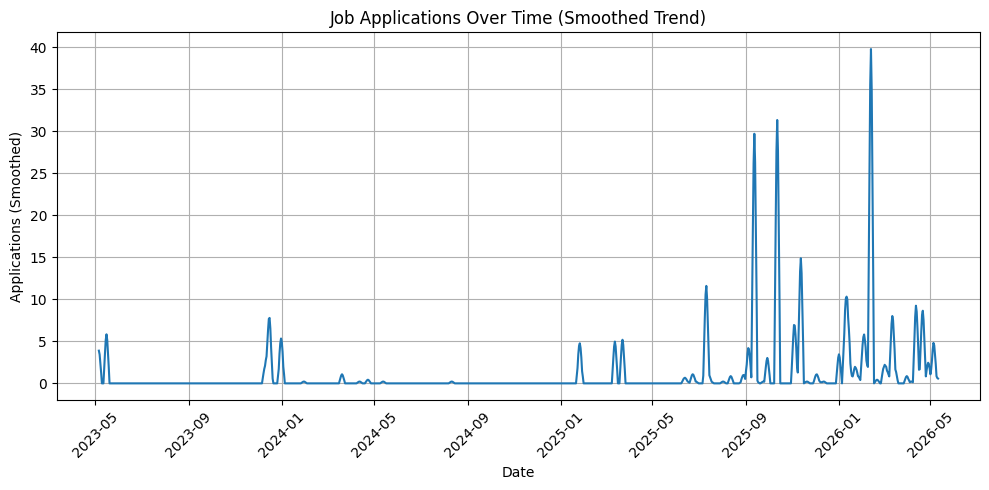

In [204]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_all["applied_date"] = pd.to_datetime(df_all["applied_date"])

# daily counts (fill missing days to avoid jagged gaps)
apps_per_day = df_all.groupby("applied_date").size().sort_index()
apps_per_day = apps_per_day.asfreq("D", fill_value=0)

# Gaussian-like smoothing (simple convolution)
window = 7
weights = np.exp(-0.5 * ((np.arange(window) - window//2) / 2)**2)
weights /= weights.sum()

smooth = np.convolve(apps_per_day.values, weights, mode="same")

plt.figure(figsize=(10,5))
plt.plot(apps_per_day.index, smooth)

plt.title("Job Applications Over Time (Smoothed Trend)")
plt.xlabel("Date")
plt.ylabel("Applications (Smoothed)")
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

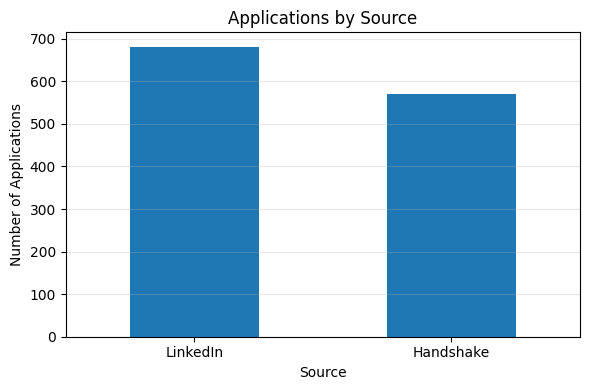

In [205]:
# Now if you look here, we can see where my problem was... I didn't apply pretty much at all between, 2024-05, and 2025-05,
# And then I graduated into the worst job market, maybe ever? For junior devs with no exp, it's war out there
# but, not to be whiny, EOD 100% my fault.

import matplotlib.pyplot as plt

source_counts = df_all["source"].value_counts()

plt.figure(figsize=(6,4))
source_counts.plot(kind="bar")

plt.title("Applications by Source")
plt.xlabel("Source")
plt.ylabel("Number of Applications")
plt.grid(axis="y", alpha=0.3)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

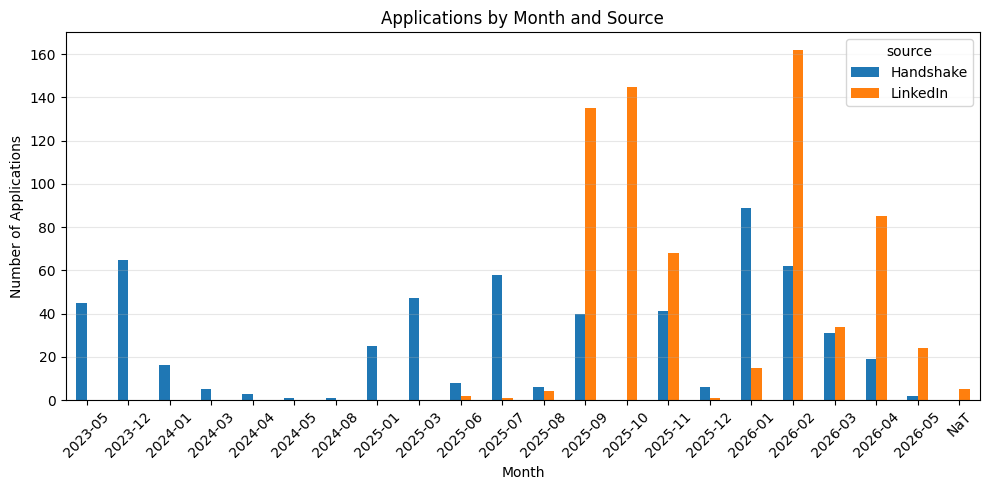

In [206]:
import pandas as pd
import matplotlib.pyplot as plt

df_all["applied_date"] = pd.to_datetime(df_all["applied_date"])

# create month column
df_all["month"] = df_all["applied_date"].dt.to_period("M").astype(str)

# group by month + source
monthly = df_all.groupby(["month", "source"]).size().unstack(fill_value=0)

# plot
monthly.plot(kind="bar", figsize=(10,5))

plt.title("Applications by Month and Source")
plt.xlabel("Month")
plt.ylabel("Number of Applications")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

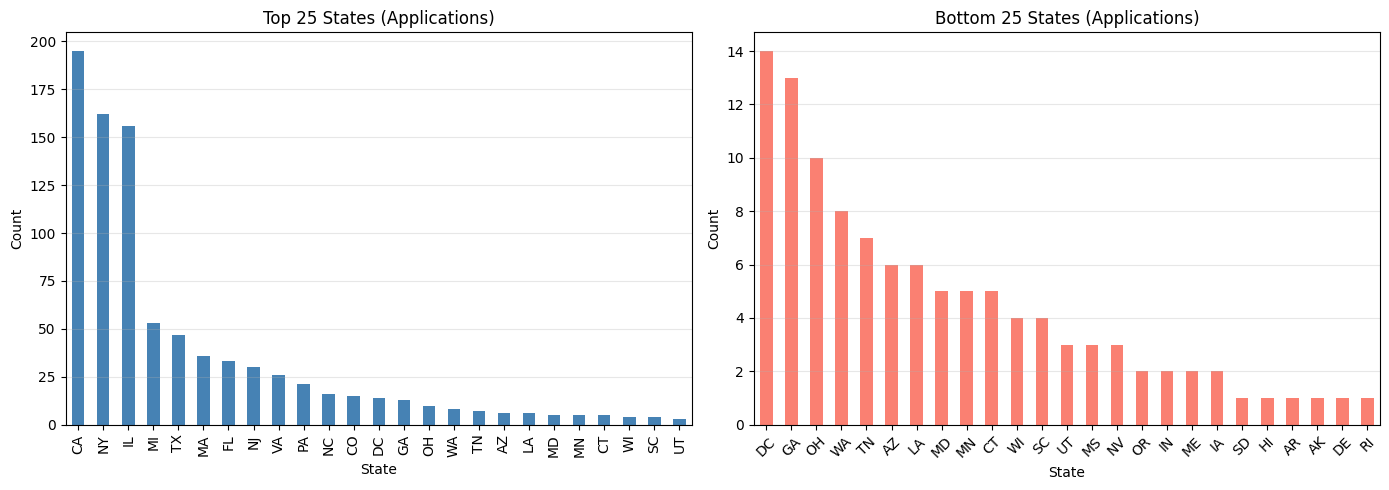

In [209]:
import matplotlib.pyplot as plt

state_counts = df_all["state"].value_counts().dropna()

top10 = state_counts.head(25)
bottom10 = state_counts.tail(25)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Top 10 states
top10.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Top 25 States (Applications)")
axes[0].set_xlabel("State")
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", alpha=0.3)

# Bottom 10 states
bottom10.plot(kind="bar", ax=axes[1], color="salmon")
axes[1].set_title("Bottom 25 States (Applications)")
axes[1].set_xlabel("State")
axes[1].set_ylabel("Count")
axes[1].grid(axis="y", alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

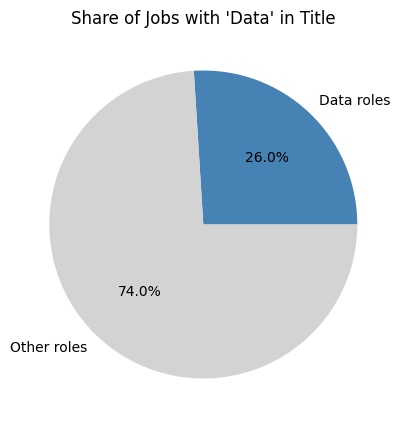

In [210]:
import matplotlib.pyplot as plt

df_all["has_data"] = df_all["title"].str.contains(r"\bdata\b", case=False, na=False)

data_pct = df_all["has_data"].mean() * 100
non_data_pct = 100 - data_pct

plt.figure(figsize=(5,5))
plt.pie(
    [data_pct, non_data_pct],
    labels=["Data roles", "Other roles"],
    autopct="%1.1f%%",
    colors=["steelblue", "lightgray"]
)

plt.title("Share of Jobs with 'Data' in Title")
plt.show()

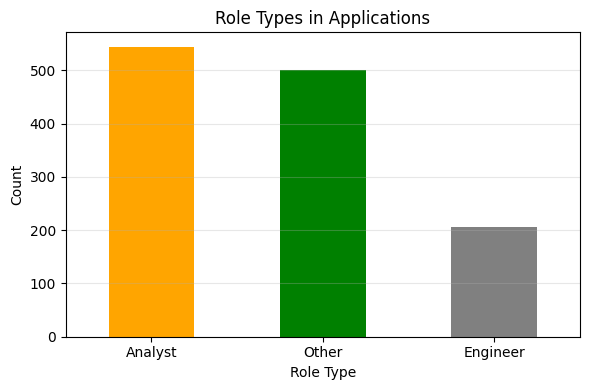

In [211]:
import numpy as np

df_all["role_type"] = np.select(
    [
        df_all["title"].str.contains("analyst", case=False, na=False),
        df_all["title"].str.contains("engineer", case=False, na=False),
    ],
    ["Analyst", "Engineer"],
    default="Other"
)

role_counts = df_all["role_type"].value_counts()

plt.figure(figsize=(6,4))
role_counts.plot(kind="bar", color=["orange", "green", "gray"])

plt.title("Role Types in Applications")
plt.xlabel("Role Type")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
df_all["work_type"].value_counts().plot(kind="bar")